# GSM8K CSD Result Summary

This notebook reads `benchmark/gsm8k/csd_runs/result.jsonl`, flattens the benchmark metadata, and recomputes speculative success rate with the corrected formula:

```python
spec_success_rate_correct = (accept_length - 1) / speculative_num_steps
```

The original `spec_success_rate` column is kept as `old_spec_success_rate` for comparison, because older rows may have used `num_draft_tokens` instead of `num_steps` as the denominator.

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

result_path = Path("/home/zhouxuwen/sglang/benchmark/gsm8k/csd_runs/result.jsonl")
if not result_path.exists():
    result_path = Path("benchmark/gsm8k/csd_runs/result.jsonl")

output_dir = result_path.parent / "plots"
output_dir.mkdir(parents=True, exist_ok=True)

result_path, output_dir

(PosixPath('/home/zhouxuwen/sglang/benchmark/gsm8k/csd_runs/result.jsonl'),
 PosixPath('/home/zhouxuwen/sglang/benchmark/gsm8k/csd_runs/plots'))

In [2]:
def infer_mode(run_tag, spec, csd):
    tag = str(run_tag or "").lower()
    if tag.startswith("baseline") or spec.get("algorithm") in (None, "none"):
        return "baseline"
    if tag.startswith("record"):
        return "record"
    if tag.startswith("csd"):
        return "csd"
    if tag.startswith("vanilla") or not csd.get("enabled", False):
        return "vanilla"
    return "unknown"


def parse_from_tag(run_tag, name):
    match = re.search(rf"{name}([0-9]+(?:p[0-9]+)?)", str(run_tag or ""))
    if not match:
        return np.nan
    value = match.group(1).replace("p", ".")
    return float(value) if "." in value else int(value)


def load_result_jsonl(path):
    rows = []
    with Path(path).open() as fin:
        for line_no, line in enumerate(fin, start=1):
            line = line.strip()
            if not line:
                continue
            record = json.loads(line)
            other = record.get("other", {}) or {}
            spec = other.get("speculative", {}) or {}
            csd = other.get("csd", {}) or {}
            run_tag = other.get("run_tag", record.get("run_tag", ""))
            parallel = other.get("parallel", parse_from_tag(run_tag, "parallel"))
            temperature = other.get("temperature", parse_from_tag(run_tag, "temp"))

            rows.append(
                {
                    "line_no": line_no,
                    "run_tag": run_tag,
                    "mode": infer_mode(run_tag, spec, csd),
                    "task": record.get("task", other.get("task")),
                    "dataset": other.get("dataset"),
                    "num_requests": record.get("num_requests", other.get("num_questions")),
                    "temperature": temperature,
                    "top_p": other.get("top_p"),
                    "parallel": parallel,
                    "accuracy": record.get("accuracy", other.get("accuracy")),
                    "invalid": record.get("invalid", other.get("invalid")),
                    "latency": record.get("latency", other.get("latency")),
                    "throughput": record.get("throughput", other.get("throughput")),
                    "accept_length": record.get("accept_length", other.get("accept_length")),
                    "old_spec_success_rate": record.get("spec_success_rate", other.get("spec_success_rate")),
                    "spec_output_token_saved_ratio": record.get("spec_output_token_saved_ratio", other.get("spec_output_token_saved_ratio")),
                    "spec_verify_ct": record.get("spec_verify_ct", other.get("spec_verify_ct")),
                    "spec_accept_token_num": record.get("spec_accept_token_num", other.get("spec_accept_token_num")),
                    "spec_draft_token_num": record.get("spec_draft_token_num", other.get("spec_draft_token_num")),
                    "spec_algorithm": spec.get("algorithm"),
                    "num_steps": spec.get("num_steps"),
                    "eagle_topk": spec.get("eagle_topk"),
                    "num_draft_tokens": spec.get("num_draft_tokens"),
                    "csd_enabled": csd.get("enabled"),
                    "csd_dynamic_update": csd.get("dynamic_update"),
                    "csd_force_accept_disabled": csd.get("force_accept_disabled"),
                    "csd_freq_threshold": csd.get("freq_threshold"),
                    "csd_prob_ratio": csd.get("prob_ratio"),
                    "csd_table_path": csd.get("table_path"),
                    "csd_save_table_path": csd.get("save_table_path"),
                    "csd_forced_accept_ct": other.get("csd_forced_accept_ct", record.get("csd_forced_accept_ct", 0)),
                    "csd_lookup_hit_ct": other.get("csd_lookup_hit_ct", record.get("csd_lookup_hit_ct", 0)),
                    "csd_delta_pair_ct": other.get("csd_delta_pair_ct", record.get("csd_delta_pair_ct", 0)),
                }
            )
    return pd.DataFrame(rows)


df = load_result_jsonl(result_path)
numeric_cols = [
    "num_requests",
    "temperature",
    "top_p",
    "parallel",
    "accuracy",
    "invalid",
    "latency",
    "throughput",
    "accept_length",
    "old_spec_success_rate",
    "spec_output_token_saved_ratio",
    "spec_verify_ct",
    "spec_accept_token_num",
    "spec_draft_token_num",
    "num_steps",
    "eagle_topk",
    "num_draft_tokens",
    "csd_freq_threshold",
    "csd_prob_ratio",
    "csd_forced_accept_ct",
    "csd_lookup_hit_ct",
    "csd_delta_pair_ct",
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

num_steps = df["num_steps"].where(df["num_steps"] > 0)
df["spec_success_rate_correct"] = ((df["accept_length"] - 1.0) / num_steps).where(num_steps.notna(), 0.0)
df["spec_success_rate_correct"] = df["spec_success_rate_correct"].clip(lower=0.0)
df["spec_success_rate_delta"] = df["spec_success_rate_correct"] - df["old_spec_success_rate"].fillna(0.0)
df["csd_force_accept_per_verify"] = np.where(
    df["spec_verify_ct"].fillna(0) > 0,
    df["csd_forced_accept_ct"].fillna(0) / df["spec_verify_ct"],
    0.0,
)
df["csd_force_accept_per_lookup"] = np.where(
    df["csd_lookup_hit_ct"].fillna(0) > 0,
    df["csd_forced_accept_ct"].fillna(0) / df["csd_lookup_hit_ct"],
    0.0,
)

mode_order = {"baseline": 0, "vanilla": 1, "record": 2, "csd": 3, "unknown": 9}
df["mode_order"] = df["mode"].map(mode_order).fillna(9)
df = df.sort_values(["temperature", "parallel", "mode_order", "num_steps", "eagle_topk"], na_position="last").reset_index(drop=True)

print(f"Loaded {len(df)} rows from {result_path}")
display(df[["run_tag", "mode", "parallel", "accept_length", "num_steps", "old_spec_success_rate", "spec_success_rate_correct", "spec_success_rate_delta"]])

Loaded 6 rows from /home/zhouxuwen/sglang/benchmark/gsm8k/csd_runs/result.jsonl


,run_tag,mode,parallel,accept_length,num_steps,old_spec_success_rate,spec_success_rate_correct,spec_success_rate_delta
0,baseline_temp0p0_parallel1,baseline,1,1.000,NaN,0.000000,0.0000,0.000000
1,record_temp0p0_parallel1,record,1,5.255,5.0,0.851025,0.8510,-0.000025
2,csd_temp0p0_parallel1,csd,1,5.407,5.0,0.881486,0.8814,-0.000086
3,baseline_temp0p0_parallel8,baseline,8,1.000,NaN,0.000000,0.0000,0.000000
4,record_temp0p0_parallel8,record,8,5.242,5.0,0.303358,0.8484,0.545042
5,csd_temp0p0_parallel8,csd,8,5.417,5.0,0.318869,0.8834,0.564531


## Presentation table

`spec_success_rate_correct` is the display metric to use in slides. `old_spec_success_rate` is only kept to show which rows were previously computed with a different denominator.

In [3]:
baseline = (
    df[df["mode"] == "baseline"]
    [["temperature", "parallel", "throughput", "latency", "accuracy"]]
    .rename(
        columns={
            "throughput": "baseline_throughput",
            "latency": "baseline_latency",
            "accuracy": "baseline_accuracy",
        }
    )
)
summary = df.merge(baseline, on=["temperature", "parallel"], how="left")
summary["throughput_speedup_vs_baseline"] = summary["throughput"] / summary["baseline_throughput"]
summary["latency_speedup_vs_baseline"] = summary["baseline_latency"] / summary["latency"]
summary["accuracy_delta_vs_baseline"] = summary["accuracy"] - summary["baseline_accuracy"]

presentation_cols = [
    "temperature",
    "parallel",
    "mode",
    "accuracy",
    "accuracy_delta_vs_baseline",
    "latency",
    "throughput",
    "throughput_speedup_vs_baseline",
    "accept_length",
    "num_steps",
    "eagle_topk",
    "num_draft_tokens",
    "spec_success_rate_correct",
    "old_spec_success_rate",
    "spec_success_rate_delta",
    "spec_output_token_saved_ratio",
    "spec_verify_ct",
    "csd_lookup_hit_ct",
    "csd_forced_accept_ct",
    "csd_force_accept_per_verify",
    "csd_force_accept_per_lookup",
    "csd_delta_pair_ct",
]
presentation = summary[presentation_cols].copy()
presentation = presentation.rename(
    columns={
        "temperature": "temp",
        "latency": "latency_s",
        "throughput": "throughput_tok_s",
        "throughput_speedup_vs_baseline": "speedup_x",
        "accept_length": "accept_len",
        "spec_success_rate_correct": "spec_success_rate_correct",
        "spec_output_token_saved_ratio": "saved_ratio",
    }
)

round_map = {
    "accuracy": 3,
    "accuracy_delta_vs_baseline": 3,
    "latency_s": 3,
    "throughput_tok_s": 3,
    "speedup_x": 3,
    "accept_len": 3,
    "spec_success_rate_correct": 3,
    "old_spec_success_rate": 3,
    "spec_success_rate_delta": 3,
    "saved_ratio": 3,
    "csd_force_accept_per_verify": 3,
    "csd_force_accept_per_lookup": 3,
}
presentation_rounded = presentation.round(round_map)

display(presentation_rounded)

,temp,parallel,mode,accuracy,accuracy_delta_vs_baseline,latency_s,throughput_tok_s,speedup_x,accept_len,num_steps,eagle_topk,num_draft_tokens,spec_success_rate_correct,old_spec_success_rate,spec_success_rate_delta,saved_ratio,spec_verify_ct,csd_lookup_hit_ct,csd_forced_accept_ct,csd_force_accept_per_verify,csd_force_accept_per_lookup,csd_delta_pair_ct
0,0.0,1,baseline,0.857,0.000,1123.868,210.746,1.000,1.000,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0
1,0.0,1,record,0.851,-0.006,756.582,311.516,1.478,5.255,5.0,3.0,15.0,0.851,0.851,-0.000,0.810,44849,0,0,0.000,0.000,45520
2,0.0,1,csd,0.936,0.079,849.709,237.728,1.128,5.407,5.0,3.0,15.0,0.881,0.881,-0.000,0.815,37356,21894,9291,0.249,0.424,0
3,0.0,8,baseline,0.859,0.000,345.383,696.267,1.000,1.000,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0,0,0,0.000,0.000,0
4,0.0,8,record,0.861,0.002,279.318,849.558,1.220,5.242,5.0,3.0,15.0,0.848,0.303,0.545,0.809,45272,0,0,0.000,0.000,46231
5,0.0,8,csd,0.938,0.079,231.036,877.532,1.260,5.417,5.0,3.0,15.0,0.883,0.319,0.565,0.815,37428,21743,9307,0.249,0.428,0


In [4]:
def dataframe_to_markdown(table):
    table = table.copy()
    table = table.where(pd.notna(table), "")
    headers = [str(col) for col in table.columns]
    rows = [[str(value) for value in row] for row in table.to_numpy()]
    widths = [len(header) for header in headers]
    for row in rows:
        widths = [max(width, len(value)) for width, value in zip(widths, row)]
    header_line = "| " + " | ".join(header.ljust(width) for header, width in zip(headers, widths)) + " |"
    sep_line = "| " + " | ".join("-" * width for width in widths) + " |"
    row_lines = ["| " + " | ".join(value.ljust(width) for value, width in zip(row, widths)) + " |" for row in rows]
    return "\n".join([header_line, sep_line, *row_lines])

csv_path = output_dir / "gsm8k_csd_summary_corrected.csv"
md_path = output_dir / "gsm8k_csd_summary_corrected.md"
presentation_rounded.to_csv(csv_path, index=False)
md_path.write_text(dataframe_to_markdown(presentation_rounded), encoding="utf-8")

print(f"Saved CSV: {csv_path}")
print(f"Saved Markdown: {md_path}")

Saved CSV: /home/zhouxuwen/sglang/benchmark/gsm8k/csd_runs/plots/gsm8k_csd_summary_corrected.csv
Saved Markdown: /home/zhouxuwen/sglang/benchmark/gsm8k/csd_runs/plots/gsm8k_csd_summary_corrected.md


## Plots

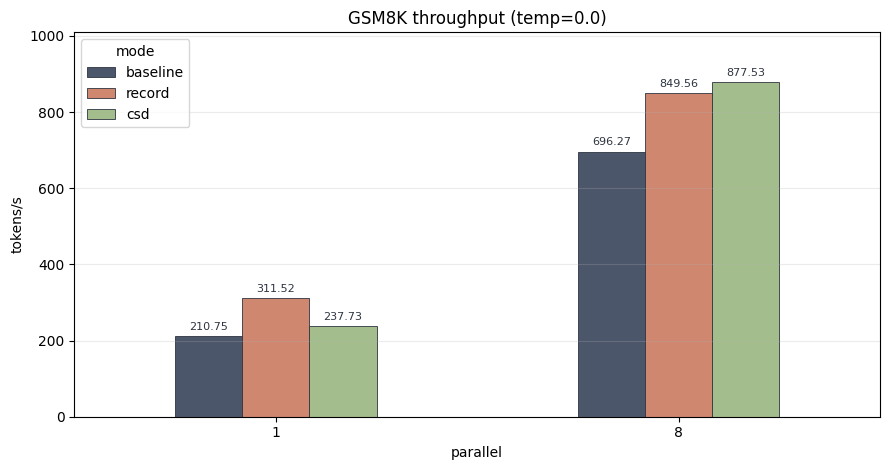

Saved plot: /home/zhouxuwen/sglang/benchmark/gsm8k/csd_runs/plots/gsm8k_throughput_temp0p0.png


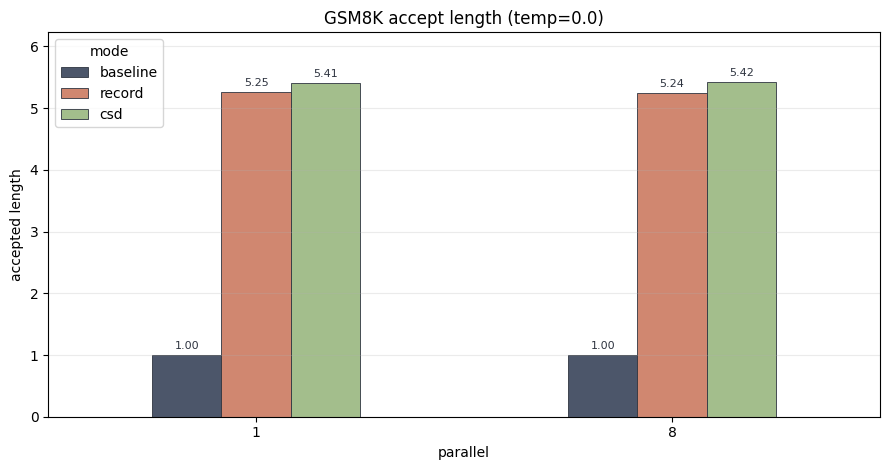

Saved plot: /home/zhouxuwen/sglang/benchmark/gsm8k/csd_runs/plots/gsm8k_accept_length_temp0p0.png


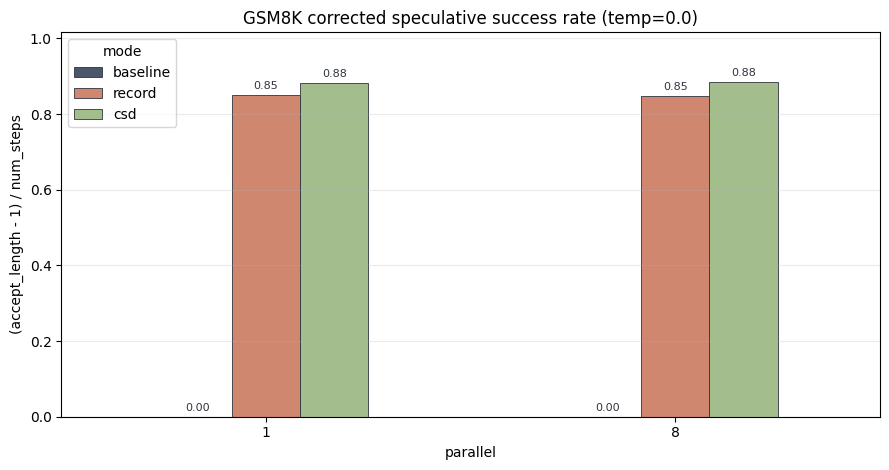

Saved plot: /home/zhouxuwen/sglang/benchmark/gsm8k/csd_runs/plots/gsm8k_spec_success_rate_correct_temp0p0.png


In [9]:
plot_modes = [mode for mode in ["baseline", "vanilla", "record", "csd"] if mode in set(df["mode"])]
colors = {
    "baseline": "#4C566A",
    "vanilla": "#5E81AC",
    "record": "#D08770",
    "csd": "#A3BE8C",
}

def plot_grouped_bar(data, value_col, ylabel, title, filename, ylim=None):
    pivot = (
        data.pivot_table(index="parallel", columns="mode", values=value_col, aggfunc="mean")
        .reindex(columns=plot_modes)
        .sort_index()
    )
    ax = pivot.plot(
        kind="bar",
        figsize=(9, 4.8),
        color=[colors.get(col, None) for col in pivot.columns],
        edgecolor="#2E3440",
        linewidth=0.6,
    )
    
    # ================= 新增代码开始 =================
    # 遍历所有的柱子容器，并添加数据标签
    for container in ax.containers:
        # fmt="%.2f" 表示保留两位小数，你可以根据需要改成 "%.1f" 或 "%g"
        # padding=3 表示标签距离柱子顶部的像素距离
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=8, color="#2E3440")
    # ================= 新增代码结束 =================

    ax.set_title(title)
    ax.set_xlabel("parallel")
    ax.set_ylabel(ylabel)
    
    # 处理 Y 轴上限
    if ylim is not None:
        ax.set_ylim(*ylim)
    else:
        # 如果没有指定 ylim，自动将最大值拉高 15%，防止顶部数据标签被截断
        y_max = pivot.max().max()
        # 如果 y_max 是 NaN，给个默认值防止报错
        if pd.isna(y_max):
            y_max = 1.0
        ax.set_ylim(0, y_max * 1.15)
        
    ax.grid(axis="y", alpha=0.25)
    ax.legend(title="mode")
    plt.xticks(rotation=0)
    plt.tight_layout()
    
    path = output_dir / filename
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved plot: {path}")

plot_df = df[df["mode"].isin(plot_modes)].copy()
for temp, sub in plot_df.groupby("temperature", dropna=False):
    temp_label = "unknown" if pd.isna(temp) else str(temp).replace(".", "p")
    title_suffix = f"temp={temp}" if not pd.isna(temp) else "temp=unknown"
    plot_grouped_bar(
        sub,
        "throughput",
        "tokens/s",
        f"GSM8K throughput ({title_suffix})",
        f"gsm8k_throughput_temp{temp_label}.png",
    )
    plot_grouped_bar(
        sub,
        "accept_length",
        "accepted length",
        f"GSM8K accept length ({title_suffix})",
        f"gsm8k_accept_length_temp{temp_label}.png",
    )
    plot_grouped_bar(
        sub,
        "spec_success_rate_correct",
        "(accept_length - 1) / num_steps",
        f"GSM8K corrected speculative success rate ({title_suffix})",
        f"gsm8k_spec_success_rate_correct_temp{temp_label}.png",
        ylim=(0, max(1.0, sub["spec_success_rate_correct"].max() * 1.15)),
    )

## Slide-ready compact table

In [ ]:
slide_cols = [
    "temp",
    "parallel",
    "mode",
    "accuracy",
    "throughput_tok_s",
    "speedup_x",
    "accept_len",
    "spec_success_rate_correct",
    "csd_lookup_hit_ct",
    "csd_forced_accept_ct",
]
slide_table = presentation_rounded[slide_cols].copy()
slide_table_path = output_dir / "gsm8k_csd_slide_table_corrected.md"
slide_table_path.write_text(dataframe_to_markdown(slide_table), encoding="utf-8")
display(slide_table)
print(f"Saved slide table: {slide_table_path}")

,temp,parallel,mode,accuracy,throughput_tok_s,speedup_x,accept_len,spec_success_rate_correct,saved_ratio,csd_lookup_hit_ct,csd_forced_accept_ct
0,0.0,1,baseline,0.857,210.746,1.000,1.000,0.000,0.000,0,0
1,0.0,1,record,0.851,311.516,1.478,5.255,0.851,0.810,0,0
2,0.0,1,csd,0.936,237.728,1.128,5.407,0.881,0.815,21894,9291
3,0.0,8,baseline,0.859,696.267,1.000,1.000,0.000,0.000,0,0
4,0.0,8,record,0.861,849.558,1.220,5.242,0.848,0.809,0,0
5,0.0,8,csd,0.938,877.532,1.260,5.417,0.883,0.815,21743,9307


Saved slide table: /home/zhouxuwen/sglang/benchmark/gsm8k/csd_runs/plots/gsm8k_csd_slide_table_corrected.md
